# 4 Nearest Neighbors
### Team Members: June, Anh, Tara, Jackson

# Data Cleaning

In [73]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv", low_memory=False)
test_df = pd.read_csv("test.csv", low_memory=False)

missing_placeholders = ["UNKNOWN", "ZZZZ"]

train_df = train_df.replace(missing_placeholders, np.nan)
test_df = test_df.replace(missing_placeholders, np.nan)

print(train_df.shape)
train_df.head()


(307178, 55)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


Make Sure there are no duplicates. The duplicate count equals zero, so we don't handle duplicates.

In [74]:
duplicate_count = train_df.duplicated().sum()
print("Duplicate Count: ", duplicate_count)

Duplicate Count:  0


Drop columns that are not useful or have a high missing value fraction. We also save `INDEX_NR` separately as `train_ids` and `test_ids`, then remove it from the model features so the model does not learn from the incident identifier. Since `INCIDENT_DATE` is kept as the encoded calendar date, we remove `INCIDENT_MONTH` and `INCIDENT_YEAR` as redundant date-derived fields. Feature engineer the runway column into `airborne` where it is 1 if blank and 0 if it occured on runway.

In [75]:
missing_summary = (
    train_df.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_fraction")
)

missing_summary.head(20)

high_missing_cols = missing_summary[missing_summary["missing_fraction"] > 0.95].index.tolist()
high_missing_cols


manual_drop_cols = [
    "BIRD_BAND_NUMBER",   # almost entirely missing and not useful for prediction
    "REMARKS",            # free-text notes, difficult to use in simple models
    "COMMENTS",           # free-text notes, difficult to use in simple models
    "LUPDATE",            # administrative update date, not strike condition
    "TRANSFER",           # administrative field
    "REG",
    "LOCATION"            # Dropped b/c free text, not standardized
]

target_col = "INDICATED_DAMAGE"
id_col = "INDEX_NR"

train_ids = train_df[id_col].copy()
test_ids = test_df[id_col].copy()

model_only_drop_cols = [
    id_col,  # Keep separately for matching predictions, but exclude from model features.
    "INCIDENT_MONTH",  # Redundant with INCIDENT_DATE.
    "INCIDENT_YEAR",   # Redundant with INCIDENT_DATE.
]

cols_to_drop = sorted(set(high_missing_cols + manual_drop_cols + model_only_drop_cols))

X = train_df.drop(columns=[target_col] + cols_to_drop, errors="ignore")
y = train_df[target_col]

X_test = test_df.drop(columns=cols_to_drop, errors="ignore")

for feature_df in (X, X_test):
    runway_is_blank = feature_df["RUNWAY"].isna() | feature_df["RUNWAY"].astype(str).str.strip().eq("")
    feature_df["airborne"] = runway_is_blank.astype(int)
    feature_df.drop(columns=["RUNWAY"], inplace=True)

print("Dropped columns:")
print(cols_to_drop)

print("Training features shape:", X.shape)
print("Test features shape:", X_test.shape)
print("Train IDs shape:", train_ids.shape)
print("Test IDs shape:", test_ids.shape)




Dropped columns:
['BIRD_BAND_NUMBER', 'COMMENTS', 'ENG_3_POS', 'ENG_4_POS', 'ENROUTE_STATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'INDEX_NR', 'LOCATION', 'LUPDATE', 'PRECIPITATION', 'REG', 'REMARKS', 'TRANSFER']
Training features shape: (307178, 40)
Test features shape: (34131, 40)
Train IDs shape: (307178,)
Test IDs shape: (34131,)


`INDEX_NR` is now kept outside the feature matrices. Later, after generating test predictions, we can match predictions back to incidents with:

```python
submission = pd.DataFrame({
    id_col: test_ids,
    target_col: test_predictions,
})
```

This preserves the ID for reporting or Kaggle submission without letting it influence the model.

Drop training rows where the majority of the remaining feature values are missing. We use a 50% threshold because this directly matches our definition of "majority missing information" and removes only the most incomplete records. We do not drop rows from `test_df` because Kaggle requires a prediction for every test row.

In [76]:
row_missing_fraction = X.isna().mean(axis=1)

row_missing_summary = row_missing_fraction.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
print(row_missing_summary)

missing_row_threshold = 0.50
rows_to_keep = row_missing_fraction <= missing_row_threshold

rows_removed = (~rows_to_keep).sum()
percent_removed = rows_removed / len(X) * 100

X = X.loc[rows_to_keep].copy()
y = y.loc[rows_to_keep].copy()
train_ids = train_ids.loc[rows_to_keep].copy()

print(f"Rows removed: {rows_removed} ({percent_removed:.2f}% of training data)")
print("Cleaned training features shape:", X.shape)
print("Cleaned target shape:", y.shape)
print("Cleaned train IDs shape:", train_ids.shape)


count    307178.000000
mean          0.227836
std           0.190701
min           0.000000
50%           0.125000
75%           0.475000
90%           0.500000
95%           0.500000
99%           0.500000
max           0.700000
dtype: float64
Rows removed: 463 (0.15% of training data)
Cleaned training features shape: (306715, 40)
Cleaned target shape: (306715,)
Cleaned train IDs shape: (306715,)


Convert `INCIDENT_DATE` into Unix seconds for the calendar date, and convert `TIME` into minutes after midnight so it represents time of day instead of duplicating the incident date.

In [77]:
def datetime_to_unix_seconds(datetime_series):
    unix_seconds = datetime_series.astype("int64") // 10**9
    return unix_seconds.where(datetime_series.notna(), np.nan).astype("float64")


def time_to_minutes_after_midnight(time_series):
    parsed_time = pd.to_datetime(time_series.astype("string").str.strip(), format="%H:%M", errors="coerce")
    minutes = parsed_time.dt.hour * 60 + parsed_time.dt.minute
    return minutes.astype("float64")


for feature_df in (X, X_test):
    incident_date = pd.to_datetime(feature_df["INCIDENT_DATE"], format="%m/%d/%y", errors="coerce")

    feature_df["INCIDENT_DATE"] = datetime_to_unix_seconds(incident_date)
    feature_df["TIME"] = time_to_minutes_after_midnight(feature_df["TIME"])

print(X[["INCIDENT_DATE", "TIME"]].dtypes)
X[["INCIDENT_DATE", "TIME"]].head()


INCIDENT_DATE    float64
TIME             float64
dtype: object


,INCIDENT_DATE,TIME
0,7.557408e+08,NaN
1,1.264982e+09,300.0
2,1.336522e+09,120.0
3,1.034035e+09,NaN
4,8.549280e+08,NaN


Check that `INCIDENT_DATE` parses correctly and that the Unix encoding matches the parsed calendar date.

In [78]:
def summarize_incident_date_encoding(raw_date_series, dataset_name):
    parsed_dates = pd.to_datetime(raw_date_series, format="%m/%d/%y", errors="coerce")
    encoded_dates = datetime_to_unix_seconds(parsed_dates)
    parse_failures = raw_date_series.notna() & parsed_dates.isna()

    return {
        "dataset": dataset_name,
        "raw_non_null": int(raw_date_series.notna().sum()),
        "parse_failures": int(parse_failures.sum()),
        "parsed_min": parsed_dates.min(),
        "parsed_max": parsed_dates.max(),
        "unix_min": encoded_dates.min(),
        "unix_max": encoded_dates.max(),
    }


date_encoding_summary = pd.DataFrame(
    [
        summarize_incident_date_encoding(train_df["INCIDENT_DATE"], "train"),
        summarize_incident_date_encoding(test_df["INCIDENT_DATE"], "test"),
    ]
)

display(date_encoding_summary)

print("Sample converted training dates:")
display(
    pd.DataFrame(
        {
            "raw_INCIDENT_DATE": train_df.loc[X.index, "INCIDENT_DATE"].head(),
            "parsed_from_unix": pd.to_datetime(X["INCIDENT_DATE"].head(), unit="s"),
            "unix_seconds": X["INCIDENT_DATE"].head(),
        }
    )
)

,dataset,raw_non_null,parse_failures,parsed_min,parsed_max,unix_min,unix_max
0,train,307178,0,1990-01-02,2026-03-12,631238400.0,1.773274e+09
1,test,34131,0,1990-01-02,2026-02-17,631238400.0,1.771286e+09


Sample converted training dates:


,raw_INCIDENT_DATE,parsed_from_unix,unix_seconds
0,12/13/93,1993-12-13,7.557408e+08
1,2/1/10,2010-02-01,1.264982e+09
2,5/9/12,2012-05-09,1.336522e+09
3,10/8/02,2002-10-08,1.034035e+09
4,2/3/97,1997-02-03,8.549280e+08


Impute the remaining missing values. Numerical features are filled with the training mean, and categorical features are filled with the training mode. The same values learned from `X` are applied to `X_test`.

In [79]:
X_test = X_test.reindex(columns=X.columns)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.columns.difference(numeric_cols).tolist()

numeric_fill_values = X[numeric_cols].mean().fillna(0)
categorical_fill_values = X[categorical_cols].agg(
    lambda col: col.mode(dropna=True).iloc[0]
    if not col.mode(dropna=True).empty
    else "Missing"
)

missing_before = pd.DataFrame(
    {
        "train_missing": X.isna().sum(),
        "test_missing": X_test.isna().sum(),
    }
)

X[numeric_cols] = X[numeric_cols].fillna(numeric_fill_values)
X_test[numeric_cols] = X_test[numeric_cols].fillna(numeric_fill_values)

X[categorical_cols] = X[categorical_cols].fillna(categorical_fill_values)
X_test[categorical_cols] = X_test[categorical_cols].fillna(categorical_fill_values)

print(f"Numeric columns imputed with mean: {len(numeric_cols)}")
print(f"Categorical columns imputed with mode: {len(categorical_cols)}")
print("Missing values before imputation:")
print(missing_before[missing_before.sum(axis=1) > 0].head(20))
print("Missing values after imputation:")
print({"train_missing": int(X.isna().sum().sum()), "test_missing": int(X_test.isna().sum().sum())})
X.head().T

Numeric columns imputed with mean: 15
Categorical columns imputed with mode: 25
Missing values before imputation:
             train_missing  test_missing
TIME                131695         14741
TIME_OF_DAY         133551         14958
AIRPORT_ID           40374          4493
AIRPORT              40374          4493
LATITUDE             40434          4510
LONGITUDE            40437          4510
STATE                40434          4510
FAAREGION            40434          4510
OPERATOR             86482          9751
FLT                 161026         18010
AIRCRAFT             86533          9798
AMA                  88467         10002
AMO                 116369         13151
EMA                 101963         11510
EMO                 112717         12667
AC_CLASS             86891          9855
AC_MASS              86991          9849
TYPE_ENG             87324          9897
NUM_ENGS             87235          9887
ENG_1_POS            87254          9891
Missing values after impu

,0,1,2,3,4
INCIDENT_DATE,755740800.0,1264982400.0,1336521600.0,1034035200.0,854928000.0
TIME,808.03703,300.0,120.0,808.03703,808.03703
TIME_OF_DAY,Day,Night,Night,Day,Dawn
AIRPORT_ID,TJSJ,WMKK,KSDF,KLAX,PHLI
AIRPORT,LUIS MUNOZ MARIN INTL,KUALA LUMPUR INTL,MUHAMMAD ALI INTERNATIONAL,LOS ANGELES INTL,LIHUE ARPT
LATITUDE,18.43942,2.745578,38.17439,33.94254,21.97598
LONGITUDE,-66.00183,101.709917,-85.736,-118.40807,-159.33896
STATE,PR,FN,KY,CA,HI
FAAREGION,ASO,FGN,ASO,AWP,AWP
OPID,AAL,FDX,UPS,UNK,1AAH


# Data Exploration


## Target Class Balance

Before modeling, we check whether the damage outcome is balanced. This helps determine whether accuracy alone is an appropriate evaluation metric or whether we should pay closer attention to recall, precision, F1-score, or ROC-AUC.

,damage_class,count,percentage
0,0,287216,93.642632
1,1,19499,6.357368


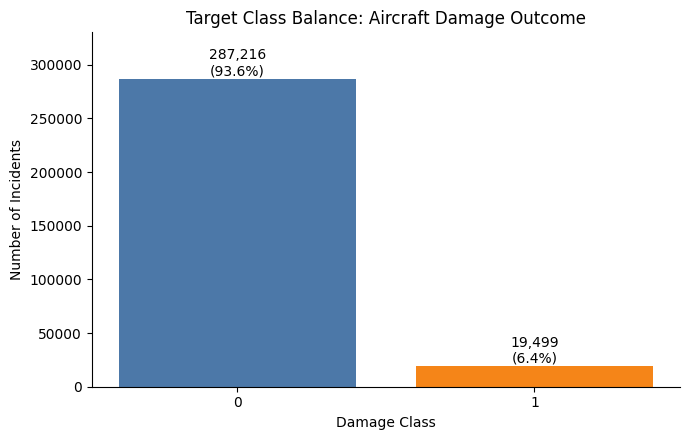

In [80]:
import matplotlib.pyplot as plt

target_balance = (
    y.value_counts(dropna=False)
    .rename_axis("damage_class")
    .reset_index(name="count")
)
target_balance["percentage"] = target_balance["count"] / target_balance["count"].sum() * 100

display(target_balance)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
bars = ax.bar(
    target_balance["damage_class"].astype(str),
    target_balance["count"],
    color=colors[: len(target_balance)],
)

for bar, count, percentage in zip(
    bars,
    target_balance["count"],
    target_balance["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
    )

ax.set_title("Target Class Balance: Aircraft Damage Outcome")
ax.set_xlabel("Damage Class")
ax.set_ylabel("Number of Incidents")
ax.set_ylim(0, target_balance["count"].max() * 1.15)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Numeric Feature Correlation Matrix

We use `DataFrame.corr(numeric_only=True)` to examine linear relationships between numeric features. This helps identify redundant numeric variables and pairs of features that may carry similar information.

In [81]:
numeric_correlation_matrix = X.corr(numeric_only=True)

print("Numeric correlation matrix shape:", numeric_correlation_matrix.shape)
display(numeric_correlation_matrix)

Numeric correlation matrix shape: (15, 15)


,INCIDENT_DATE,TIME,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,HEIGHT,SPEED,DISTANCE,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,airborne
INCIDENT_DATE,1.000000,-0.028391,-0.223119,-0.154279,0.053540,-0.126839,-0.149421,-0.199728,0.019628,0.032056,0.057041,0.034319,0.349478,0.248578,-0.073732
TIME,-0.028391,1.000000,-0.037045,-0.034258,0.009513,-0.024461,-0.011396,-0.029060,0.107016,0.070930,0.109780,-0.000651,-0.091152,0.039823,0.033377
EMA,-0.223119,-0.037045,1.000000,0.413201,0.104061,0.187524,0.114825,0.252824,0.010528,0.035962,-0.013708,-0.004620,-0.097041,-0.082789,0.022629
EMO,-0.154279,-0.034258,0.413201,1.000000,-0.083867,0.011987,0.100825,0.090066,0.020071,-0.013305,0.015042,-0.001420,-0.096304,-0.084873,0.004172
AC_MASS,0.053540,0.009513,0.104061,-0.083867,1.000000,0.562835,-0.707323,-0.346239,0.060333,0.324936,0.056880,0.018715,0.072533,0.117637,0.008428
NUM_ENGS,-0.126839,-0.024461,0.187524,0.011987,0.562835,1.000000,-0.318985,0.159864,0.033773,0.208084,0.019181,0.000932,-0.022034,-0.004226,-0.005140
ENG_1_POS,-0.149421,-0.011396,0.114825,0.100825,-0.707323,-0.318985,1.000000,0.795708,-0.081097,-0.251985,-0.084583,-0.025879,-0.074058,-0.137631,-0.037033
ENG_2_POS,-0.199728,-0.029060,0.252824,0.090066,-0.346239,0.159864,0.795708,1.000000,-0.059092,-0.096666,-0.066099,-0.025120,-0.076129,-0.132781,-0.058370
HEIGHT,0.019628,0.107016,0.010528,0.020071,0.060333,0.033773,-0.081097,-0.059092,1.000000,0.587562,0.526501,-0.001124,-0.099492,0.009254,0.103344
SPEED,0.032056,0.070930,0.035962,-0.013305,0.324936,0.208084,-0.251985,-0.096666,0.587562,1.000000,0.401091,-0.000405,-0.051110,0.017086,0.010902


## Numeric Feature Correlation Heatmap

The heatmap makes the strongest positive and negative numeric correlations easier to scan than the raw matrix.

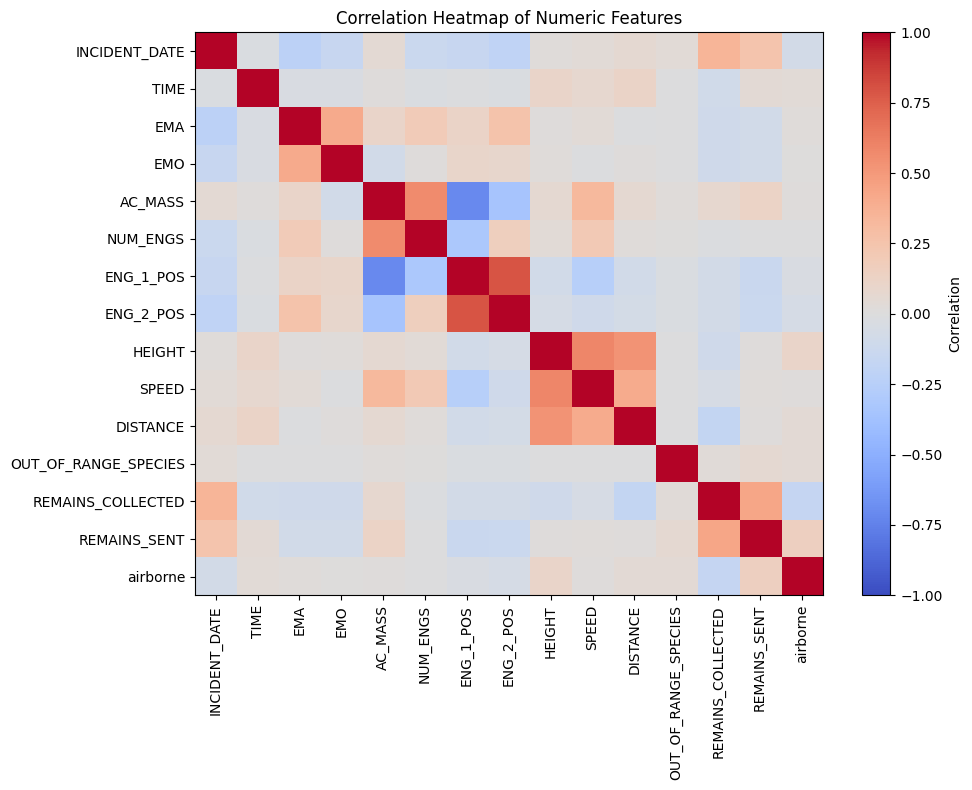

In [82]:
fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    numeric_correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_title("Correlation Heatmap of Numeric Features")
ax.set_xticks(range(len(numeric_correlation_matrix.columns)))
ax.set_yticks(range(len(numeric_correlation_matrix.index)))
ax.set_xticklabels(numeric_correlation_matrix.columns, rotation=90)
ax.set_yticklabels(numeric_correlation_matrix.index)

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Correlation")

plt.tight_layout()
plt.show()

## Numeric Correlation Conclusions

The numeric correlation matrix and heatmap show several clear relationships that should guide feature selection and modeling:

- `INCIDENT_MONTH` and `INCIDENT_YEAR` were removed from the model features because they are already encoded within `INCIDENT_DATE`. This avoids giving the model duplicate calendar information. After correcting `TIME` to minutes after midnight, it is no longer strongly correlated with the date fields and can be interpreted as time of day.
- `ENG_1_POS` and `ENG_2_POS` are very highly correlated. This suggests that engine-position variables contain overlapping information, so we should watch for redundancy. Tree-based models can usually handle this, but distance-based models such as KNN may be affected because repeated information can overweight one concept.
- `HEIGHT`, `DISTANCE`, and `SPEED` show moderate to strong positive correlations. This makes sense operationally because strikes farther from the airport or at higher altitude may occur during faster phases of flight. These features may still be useful, but we should scale them before KNN and consider whether engineered bins like low-altitude strike or takeoff/landing phase are easier to interpret.
- `INDEX_NR` is correlated with date-related fields, which suggests it behaves partly like an ordering or record identifier. Because it is not a strike condition, we should avoid using it as a predictive feature to reduce the risk of learning dataset ordering instead of real wildlife-strike patterns.
- `REMAINS_COLLECTED` and `REMAINS_SENT` are moderately correlated with each other. These may describe post-strike reporting or investigation activity rather than conditions known before damage is assessed, so we should review them for possible leakage before including them in the final model.
- Most other numeric feature pairs do not show extremely high correlation. This means there is not widespread multicollinearity among the numeric variables, but the few redundant groups above should still be handled thoughtfully.

Moving forward, we should scale numeric features for KNN, keep `INDEX_NR` outside the model as an ID-only field, use `INCIDENT_DATE` as the single encoded calendar-date feature, review possible leakage fields such as post-incident reporting variables, and supplement numeric correlation with categorical analysis because many important predictors in this dataset are categorical rather than numeric.

# Feature Engineering

### One hot encoding/frequency encoding

#### Find the high and low cardinality categorical columns

In [83]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
low_cardinality_cols = []
high_cardinality_cols = []

for col in categorical_cols:
    num_unique = X[col].nunique()
    if num_unique <= 5:
        low_cardinality_cols.append(col)
    else:
        high_cardinality_cols.append(col)

print("Low-cardinality categorical columns (one hot):")
print(low_cardinality_cols)
print()

print("High-cardinality categorical columns (frequency):")
print(high_cardinality_cols)

Low-cardinality categorical columns (one hot):
['TIME_OF_DAY', 'AC_CLASS', 'SKY', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE']

High-cardinality categorical columns (frequency):
['AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SPECIES_ID', 'SPECIES', 'SOURCE', 'PERSON']


#### Apply frequency encoding to the high cardinality columns

In [84]:
X_freq = X.copy()
X_test_freq = X_test.copy()

frequency_maps = {}

for col in high_cardinality_cols:
    freq_map = X[col].value_counts(normalize=True)
    frequency_maps[col] = freq_map

    X_freq[col] = X[col].map(freq_map)
    X_test_freq[col] = X_test[col].map(freq_map).fillna(0)

X_freq[high_cardinality_cols].head()

,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,STATE,FAAREGION,OPID,OPERATOR,FLT,AIRCRAFT,AMA,AMO,TYPE_ENG,PHASE_OF_FLIGHT,SPECIES_ID,SPECIES,SOURCE,PERSON
0,0.001855,0.001855,0.001855,0.001855,0.002233,0.321944,0.072908,0.072908,0.525514,0.010273,0.548261,0.021355,0.890899,0.651142,0.160618,0.160618,0.122739,0.183783
1,0.000130,0.000130,0.000130,0.000130,0.014978,0.016354,0.031065,0.031065,0.000075,0.006905,0.052394,0.007753,0.890899,0.651142,0.115407,0.115407,0.618291,0.103383
2,0.010296,0.010296,0.010296,0.010296,0.023070,0.321944,0.020002,0.020002,0.000163,0.013469,0.123212,0.018786,0.890899,0.651142,0.011653,0.011653,0.050288,0.103383
3,0.009083,0.009083,0.009083,0.009083,0.069896,0.105352,0.281962,0.372968,0.525514,0.331536,0.548261,0.434002,0.890899,0.651142,0.000711,0.000711,0.618291,0.338650
4,0.004434,0.004434,0.004434,0.004434,0.016585,0.105352,0.001770,0.001770,0.525514,0.007264,0.548261,0.013006,0.890899,0.109682,0.006915,0.006915,0.114598,0.338650


#### Apply one hot encoding to the low cardinality columns

In [85]:
X_encoded = pd.get_dummies(X_freq, columns=low_cardinality_cols, drop_first=False)
X_test_encoded = pd.get_dummies(X_test_freq, columns=low_cardinality_cols, drop_first=False)

X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print("Encoded training shape:", X_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (306715, 59)
Encoded test shape: (34131, 59)


### Scaling, PCA, Modeling

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
    # add model here
])

X_processed = pipeline.fit_transform(X_encoded)
X_test_processed = pipeline.transform(X_test_encoded)

print("Original training shape:", X_encoded.shape)
print("Processed training shape:", X_processed.shape)
print("Original test shape:", X_test_encoded.shape)
print("Processed test shape:", X_test_processed.shape)
for row in X_processed[:5]:
    print(row)

Original training shape: (306715, 59)
Processed training shape: (306715, 37)
Original test shape: (34131, 59)
Processed test shape: (34131, 37)
[-3.20633747 -2.97211886 -0.24990083  1.92506764 -3.45055529  1.68369375
 -2.91868199  0.98012834  3.630435    1.64794041  1.05203118 -2.07765867
 -1.38318293  0.62779149  0.03140087  0.25344609 -1.54619127 -0.49985699
 -1.09350247  0.041646   -0.02469664  0.12313039 -0.10496843 -0.5476247
  0.25282826 -0.69784257 -0.43568641  1.65899845 -1.00350601  0.13218362
  0.01143123  0.48537554 -0.75623642 -0.1839358  -0.90072731  0.350853
  0.59086406]
[-2.11705622 -0.96019684  2.37685746 -2.0285953  -1.26359223 -0.87825897
  0.94194563  1.07219308  0.82991343 -2.12371111  0.25683633 -0.50708774
  0.53888047 -0.74199155 -2.04233217 -0.20081654 -0.67628649  1.05987133
 -0.95588831 -0.23390855 -0.50489894  0.13591386 -0.09870193 -1.63543225
  0.85488265  1.03533178  1.48626035 -1.18776849 -0.95506061 -0.03314266
 -2.27961797  0.71656536  0.28787995  0.61

# Modeling Approach

## Neural Network: Multi-Layer Perceptron

We next try a neural network using `MLPClassifier`. The model uses the encoded feature matrix, scales the features, and learns nonlinear relationships between strike conditions and aircraft damage. Because the damage class is rare, we evaluate both the default `0.50` probability threshold and a lower recall-focused threshold.

In [87]:
from sklearn.model_selection import train_test_split
train_idx, valid_idx = train_test_split(
    y.index,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

y_train = y.loc[train_idx]
y_valid = y.loc[valid_idx]


In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

def evaluate_predictions(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "damage_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "damage_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "damage_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


In [89]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train_encoded = X_encoded.loc[train_idx]
X_valid_encoded = X_encoded.loc[valid_idx]

mlp_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size=1024,
                learning_rate_init=0.001,
                max_iter=75,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=5,
                random_state=42,
                verbose=False,
            ),
        ),
    ]
)

mlp_pipeline.fit(X_train_encoded, y_train)

mlp_default_predictions = mlp_pipeline.predict(X_valid_encoded)
mlp_damage_probabilities = mlp_pipeline.predict_proba(X_valid_encoded)[:, 1]
mlp_recall_threshold = 0.20
mlp_recall_predictions = (mlp_damage_probabilities >= mlp_recall_threshold).astype(int)

mlp_metrics = pd.DataFrame(
    [
        evaluate_predictions("MLP default threshold 0.50", y_valid, mlp_default_predictions),
        evaluate_predictions(f"MLP recall threshold {mlp_recall_threshold:.2f}", y_valid, mlp_recall_predictions),
    ]
)

mlp_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_valid, mlp_recall_predictions, labels=[0, 1]),
    index=["actual_no_damage", "actual_damage"],
    columns=["predicted_no_damage", "predicted_damage"],
)

display(mlp_metrics)
display(mlp_confusion_matrix)
print("MLP classification report at threshold 0.50:")
print(classification_report(y_valid, mlp_default_predictions, zero_division=0))
print(f"MLP classification report at threshold {mlp_recall_threshold:.2f}:")
print(classification_report(y_valid, mlp_recall_predictions, zero_division=0))

,model,accuracy,damage_precision,damage_recall,damage_f1
0,MLP default threshold 0.50,0.944590,0.660269,0.264615,0.377814
1,MLP recall threshold 0.20,0.917921,0.397471,0.564103,0.466349


,predicted_no_damage,predicted_damage
actual_no_damage,54108,3335
actual_damage,1700,2200


MLP classification report at threshold 0.50:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     57443
           1       0.66      0.26      0.38      3900

    accuracy                           0.94     61343
   macro avg       0.81      0.63      0.67     61343
weighted avg       0.93      0.94      0.93     61343

MLP classification report at threshold 0.20:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     57443
           1       0.40      0.56      0.47      3900

    accuracy                           0.92     61343
   macro avg       0.68      0.75      0.71     61343
weighted avg       0.93      0.92      0.92     61343



## Kaggle Submission File

Train the current MLP approach on the full encoded training data, predict the test set, and save a Kaggle-ready CSV with one row per test incident.

In [90]:
final_mlp_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size=1024,
                learning_rate_init=0.001,
                max_iter=75,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=5,
                random_state=42,
                verbose=False,
            ),
        ),
    ]
)

final_mlp_pipeline.fit(X_encoded, y)
test_predictions = final_mlp_pipeline.predict(X_test_encoded).astype(int)

submission = pd.DataFrame(
    {
        id_col: test_ids.values,
        target_col: test_predictions,
    }
)

sample_submission = pd.read_csv("sample_submission.csv")
submission = submission[sample_submission.columns]

assert len(submission) == 34131, f"Expected 34131 rows, got {len(submission)}"
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission[id_col].equals(sample_submission[id_col])

submission_path = "submission_mlp.csv"
submission.to_csv(submission_path, index=False)

print(f"Saved {submission_path} with shape {submission.shape}")
display(submission.head())
display(submission[target_col].value_counts(normalize=True).rename("prediction_fraction"))

Saved submission_mlp.csv with shape (34131, 2)


,INDEX_NR,INDICATED_DAMAGE
0,9000000,0
1,9000001,0
2,9000002,0
3,9000003,0
4,9000004,0


INDICATED_DAMAGE
0    0.977791
1    0.022209
Name: prediction_fraction, dtype: float64